In [1]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from rasterio.transform import from_origin, xy
import numpy as np
from rasterio import features
from skimage.morphology import skeletonize, medial_axis
from scipy.ndimage import distance_transform_edt
import networkx as nx

from shapely.geometry import LineString
import dask.array as da
from rasterio import windows
import rasterio
from tqdm import tqdm

from skimage.measure import find_contours
import logging
import sys
import time


# ----------------------------------------------------------------------
# Helper: force plain Python ints (prevents TypeError later)
# ----------------------------------------------------------------------
def _as_int(v):
    return int(float(v))


# ----------------------------------------------------------------------
# Logging configuration (feel free to adjust level)
# ----------------------------------------------------------------------
log = logging.getLogger("centerline")
log.setLevel(logging.INFO)  # DEBUG for more chatter
handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(
    logging.Formatter("%(asctime)s %(levelname)-8s %(message)s", "%H:%M:%S")
)
log.addHandler(handler)

log.info("=== START CENTER‑LINE PIPELINE (no labeling) ===")
t_start = time.time()


%matplotlib widget

18:18:50 INFO     === START CENTER‑LINE PIPELINE (no labeling) ===


In [2]:
gdf = gpd.read_parquet("../data/streets/streets_CH_depth1.parquet")
gdf = gdf.set_crs(epsg=4326)
gdf.head()

,geometry,type,id,tags,nodes
0,"LINESTRING (7.60124 46.74213, 7.60128 46.7421,...",way,78216,"{'access': None, 'agricultural': None, 'alt_na...","[1130782429, 8964053130, 2569390773, 256939076..."
1,"LINESTRING (7.60281 46.7426, 7.60295 46.74298,...",way,728458,"{'access': None, 'agricultural': None, 'alt_na...","[255311991, 8964053179, 8964053178]"
2,"LINESTRING (7.60439 46.74322, 7.60435 46.74324...",way,728459,"{'access': None, 'agricultural': None, 'alt_na...","[8963565604, 13076751678, 13076751680, 2552414..."
3,"LINESTRING (7.86733 46.67284, 7.8675 46.67284,...",way,1906674,"{'access': None, 'agricultural': None, 'alt_na...","[8207526, 2379155244, 9064645433, 864680153, 8..."
4,"LINESTRING (7.8642 46.67153, 7.86449 46.6715, ...",way,1906703,"{'access': None, 'agricultural': None, 'alt_na...","[8207710, 13260338883, 2488751842, 2379155214,..."


In [3]:
# ax = gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor="k")
# ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.CartoDB.Positron)
# plt.show()

In [4]:
gdf = gdf.to_crs(epsg=3035) 

In [5]:
from shapely.ops import unary_union

BUFFER_DIST = 100 # in meters

gdf.geometry = gdf.geometry.apply(lambda line: line.buffer(BUFFER_DIST))
merged_buffers = gpd.GeoDataFrame(geometry=[unary_union(gdf.geometry)], crs=gdf.crs)

In [6]:
# Split Multipolygons into individual Polygons if they are not touching
merged_buffers = merged_buffers.explode(index_parts=False).reset_index(drop=True)

In [7]:
def skeleton_to_weighted_graph(skel, dist):
    G = nx.Graph()
    rows, cols = np.where(skel)
    for r, c in zip(rows, cols):
        G.add_node((r, c), weight=dist[r, c])
        # 8‑neighbour offsets
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                if 0 <= nr < skel.shape[0] and 0 <= nc < skel.shape[1] and skel[nr, nc]:
                    # Edge weight = negative average distance (so Dijkstra prefers high distance)
                    w = - (dist[r, c] + dist[nr, nc]) / 2.0
                    G.add_edge((r, c), (nr, nc), weight=w)
    return G

def skeleton_to_positive_graph(skel, dist):
    """
    Returns a NetworkX Graph where each edge weight is:
        cost = max_dist - average_distance_of_the_two_pixels
    This way, paths that go through more central pixels (higher distance to edge)
    have lower cost and are preferred by shortest-path algorithms.
    8-connectivity is used (including diagonals).
    """
    G = nx.Graph()
    rows, cols = np.where(skel)
    max_dist = float(dist.max())               # biggest distance in the whole mask

    for r, c in zip(rows, cols):
        G.add_node((r, c), dist=dist[r, c])

        # 8‑connectivity (including diagonals)
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                if (0 <= nr < skel.shape[0] and
                    0 <= nc < skel.shape[1] and
                    skel[nr, nc]):
                    # Average distance of the two neighbouring pixels
                    avg = (dist[r, c] + dist[nr, nc]) / 2.0
                    # Larger avg → cheaper (more central)
                    cost = max_dist - avg
                    G.add_edge((r, c), (nr, nc), weight=cost)
    return G

In [8]:
from shapely.geometry import LineString, MultiLineString

def graph_to_lines(g, pos):
    """Return a MultiLineString representing all edges."""
    lines = []
    for u, v in g.edges():
        # Grab the coordinates of the two endpoints
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        lines.append(LineString([(x1, y1), (x2, y2)]))
    return MultiLineString(lines)

In [9]:
skel_parts = []
pixel_size = 10
tile_size = 16384  # process in 16k×16k pixel tiles

for idx, feature in merged_buffers.iterrows():
    if idx > 0:
        break  # for testing, process only first feature
    geom = feature.geometry
    bounds = geom.bounds  # minx, miny, maxx, maxy
    log.debug(f"Feature {idx}: bounds = {bounds}")

    minx, miny, maxx, maxy = bounds
    width = _as_int((maxx - minx) / pixel_size)  
    # Create a raster covering the bounding box of the geometry
    height = _as_int((maxy - miny) / pixel_size)
    transform = from_origin(minx, maxy, pixel_size, pixel_size)
    log.info(f"Raster grid: {width:,} × {height:,} pixels @ {pixel_size} units/pixel")

    profile = {
        "driver": "GTiff",
        "dtype": "uint8",
        "count": 1,
        "height": height,
        "width": width,
        "crs": gdf.crs,
        "transform": transform,
        "compress": "deflate",
    }

    total_tiles_x = (width + tile_size - 1) // tile_size
    total_tiles_y = (height + tile_size - 1) // tile_size
    total_tiles = total_tiles_x * total_tiles_y
    log.info(
        f"Processing in {total_tiles} tiles of size {tile_size}×{tile_size} pixels"
    )

    with rasterio.MemoryFile() as mem:
        with mem.open(**profile) as dst:
            log.info("Rasterising polygon (tile‑wise)…")
            with tqdm(total=total_tiles, desc="Write tiles", unit="tile") as prog:
                for row_off in range(0, height, tile_size):
                    for col_off in range(0, width, tile_size):
                        win = windows.Window(
                            col_off,  # type: ignore
                            row_off,
                            min(tile_size, width - col_off),
                            min(tile_size, height - row_off),
                        )
                        mask = features.rasterize(
                            [(geom, 1)],
                            out_shape=(int(win.height), int(win.width)),
                            transform=dst.window_transform(win),
                            fill=0,
                            dtype="uint8",
                        )
                        dst.write(mask, 1, window=win)
                        prog.update(1)

        # ------------------------------------------------------------------
        # Lazy skeletonisation (still tile‑wise, never loads full raster)
        # ------------------------------------------------------------------
        log.info("Opening raster for lazy skeletonisation …")
        with mem.open() as src:
            dask_arr = da.from_array(src.read(1), chunks=(tile_size, tile_size))  # type: ignore

            def skel_block(arr):
                """Thin the binary mask to a 1‑pixel wide skeleton."""
                return medial_axis(arr.astype(bool), return_distance=False)

            skeleton = da.map_blocks(
                skel_block, dask_arr, dtype=np.uint8
            )

            log.info("Writing skeleton raster (tile‑wise)…")
            with rasterio.MemoryFile() as ske_mem:
                with ske_mem.open(**profile) as ske_dst:
                    with tqdm(
                        total=total_tiles, desc="Skeleton tiles", unit="tile"
                    ) as prog:
                        for row_off in range(0, height, tile_size):
                            for col_off in range(0, width, tile_size):
                                win = windows.Window(
                                    col_off,  # type: ignore
                                    row_off,
                                    min(tile_size, width - col_off),
                                    min(tile_size, height - row_off),
                                )
                                block = skeleton[
                                    row_off : row_off + int(win.height),
                                    col_off : col_off + int(win.width),
                                ].compute()
                                ske_dst.write(block, 1, window=win)
                                prog.update(1)

                # --------------------------------------------------------------
                # build weighted graph from full skeleton
                # --------------------------------------------------------------
                log.info("Building graph from skeleton …")
                with ske_mem.open() as ske_src:
                    full_skel = ske_src.read(1) > 0 

                dist = distance_transform_edt(full_skel)

                G = skeleton_to_positive_graph(full_skel, dist)

18:18:52 INFO     Raster grid: 27,718 × 16,990 pixels @ 10 units/pixel
18:18:52 INFO     Processing in 4 tiles of size 16384×16384 pixels
18:18:52 INFO     Rasterising polygon (tile‑wise)…


Write tiles: 100%|██████████| 4/4 [00:04<00:00,  1.24s/tile]


18:18:58 INFO     Opening raster for lazy skeletonisation …
18:18:59 INFO     Writing skeleton raster (tile‑wise)…


Skeleton tiles: 100%|██████████| 4/4 [00:48<00:00, 12.21s/tile]

18:19:49 INFO     Building graph from skeleton …


In [10]:
# print number of nodes and edges
log.info(f"Graph has {G.number_of_nodes():,} nodes and {G.number_of_edges():,} edges")

18:20:10 INFO     Graph has 124,692 nodes and 124,886 edges


In [11]:
def pixel_to_world(row, col, transform=transform):
    """Apply the raster affine transform."""
    x, y = transform * (col, row)
    return x, y

def graph_to_geometries(G: nx.Graph, transform):
    """
    Returns a GeoDataFrame with a single MultiLineString geometry
    that represents every edge of the graph, correctly georeferenced.
    """
    lines = []
    for u, v, _ in G.edges(data=True):
        # u and v are (row, col) tuples
        x1, y1 = pixel_to_world(u[0], u[1], transform)
        x2, y2 = pixel_to_world(v[0], v[1], transform)
        lines.append(LineString([(x1, y1), (x2, y2)]))

    mls = MultiLineString(lines)

    # If you know the CRS (e.g., EPSG:32633), set it here.
    # Replace with the actual CRS of your raster.
    crs = "EPSG:3035"          # <-- adjust as needed
    gdf = gpd.GeoDataFrame({"geometry": [mls]}, crs=crs)
    return gdf

In [12]:
gdf_edges = graph_to_geometries(G, transform)

In [16]:
gdf_edges_smoothed = gdf_edges.simplify(tolerance=50, preserve_topology=True)

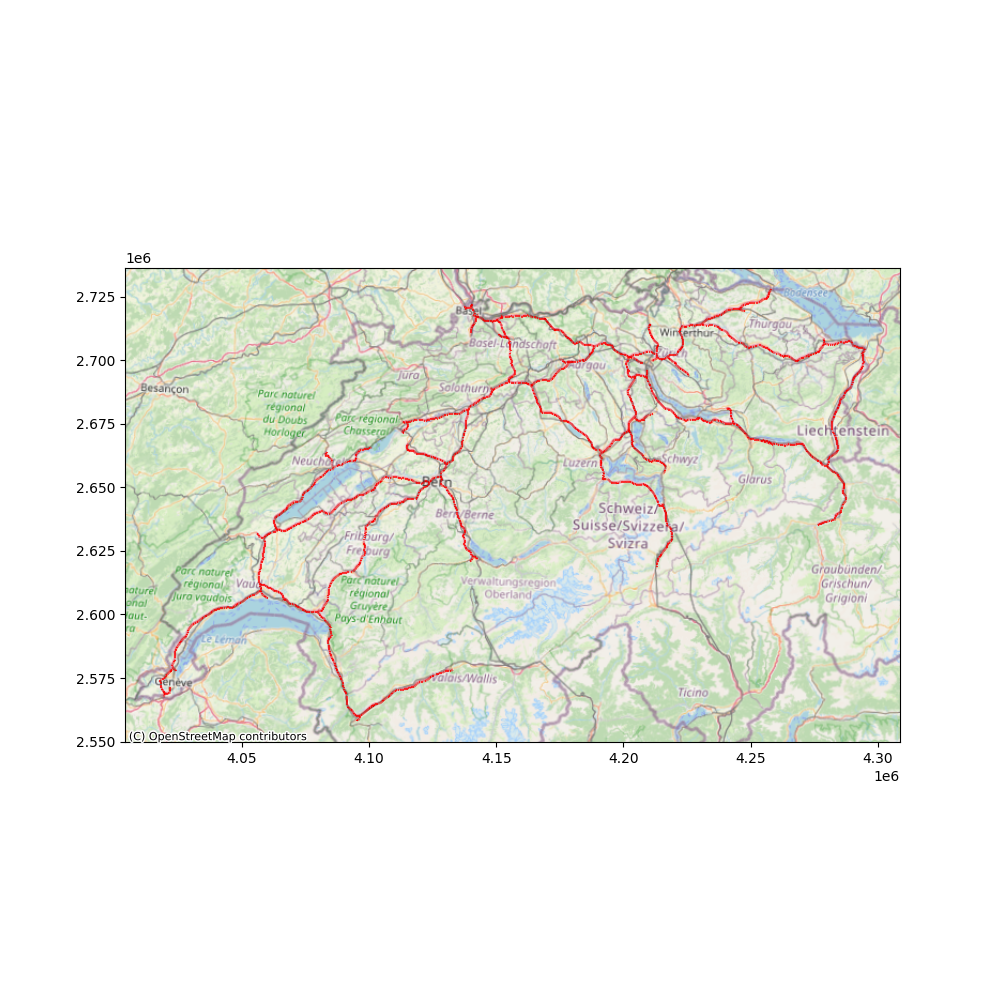

In [19]:
gdf_edges_smoothed.plot(figsize=(10, 10), alpha=0.7, edgecolor="red")
ctx.add_basemap(plt.gca(), crs=gdf_edges_smoothed.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
plt.show()

In [25]:
# export to geojson
gdf_edges_smoothed.to_file("../data/streets/streets_CH_centerlines.geojson", driver="GeoJSON")
log.info("=== END CENTER‑LINE PIPELINE ===")

18:24:15 INFO     === END CENTER‑LINE PIPELINE ===
